In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('../data/raw/fraudTrain.csv')

In [11]:
df2 = pd.read_csv('../data/raw/fraudTest.csv')

In [6]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  str    
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  str    
 4   category               1296675 non-null  str    
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  str    
 7   last                   1296675 non-null  str    
 8   gender                 1296675 non-null  str    
 9   street                 1296675 non-null  str    
 10  city                   1296675 non-null  str    
 11  state                  1296675 non-null  str    
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long                   129667

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [14]:
train_mean = df['is_fraud'].mean()
test_mean = df2['is_fraud'].mean()

In [15]:
train_mean, test_mean

(np.float64(0.005788651743883394), np.float64(0.0038598644278853163))

Converting string to Datetime

In [26]:
from datetime import datetime

In [32]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'],errors='coerce')
df2['trans_date_trans_time'] = pd.to_datetime(df2['trans_date_trans_time'],errors='coerce')

 Find the range of each dataset

In [33]:
min_date_train = df['trans_date_trans_time'].min()
max_date_train = df['trans_date_trans_time'].max()

In [34]:
min_date_test = df2['trans_date_trans_time'].min()
max_date_test = df2['trans_date_trans_time'].max()

In [37]:
min_date_train

Timestamp('2019-01-01 00:00:18')

Checking Overlapping

In [40]:
overlap_test = (min_date_test <= max_date_train) and (max_date_test >= min_date_train)

In [41]:
overlap_test

False

In [42]:
overlap_train = (min_date_train <= max_date_test) and (max_date_train >= min_date_test)

In [43]:
overlap_train

False

In [44]:
train_cards = df["cc_num"].nunique()
test_cards = df2["cc_num"].nunique()

print("Unique cards in train:", train_cards)
print("Unique cards in test:", test_cards)

Unique cards in train: 983
Unique cards in test: 924


In [45]:
train_merchants = df["merchant"].nunique()
test_merchants = df2["merchant"].nunique()

print("Unique merchants in train:", train_merchants)
print("Unique merchants in test:", test_merchants)


Unique merchants in train: 693
Unique merchants in test: 693


In [46]:
train_card_set = set(df["cc_num"])
test_card_set = set(df2["cc_num"])


In [48]:
shared_cards = train_card_set.intersection(test_card_set)

print("Cards appearing in both:", len(shared_cards))
print(shared_cards)



Cards appearing in both: 908
{4110266553600176127, 3524574586339330, 4045036286570100739, 3596217206093829, 213136802746375, 4683520018489354, 342035762534413, 4006047418382, 4348786085525522, 4561546772499, 4788103653396, 30596478689301, 4450831335606294, 3543299015720986, 3517527805128735, 4764202053279782, 4134456652433447, 4124536010991657, 4989847570577635369, 4018105808392773675, 4500002361389, 3502088871723054, 371683116218417, 6535328428560433, 4488941175228467, 2706977570537524, 38057513087029, 6544734391390261, 370818583810103, 30248898834493, 3585052663373890, 3541554378551366, 3531129874770000, 2610529083834453, 565399283797, 213153151785052, 4129767952109660, 3560797065840735, 3520550088202337, 4570636521433188, 3551217896304745, 4477156602511939689, 4951647200979051, 30092964733035, 4119762878330989, 3506040590383211, 3534718226968689, 213107169859697, 6595970453799027, 341283058448499, 4497451418073897078, 3500969075198072, 676298633337, 2703186189652095, 30103132002433,

Missing values

In [51]:
print(df.isnull().sum())


Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


In [52]:
print(df2.isnull().sum())


Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


In [54]:
print(df.dtypes)


Unnamed: 0                        int64
trans_date_trans_time    datetime64[us]
cc_num                            int64
merchant                            str
category                            str
amt                             float64
first                               str
last                                str
gender                              str
street                              str
city                                str
state                               str
zip                               int64
lat                             float64
long                            float64
city_pop                          int64
job                                 str
dob                                 str
trans_num                           str
unix_time                         int64
merch_lat                       float64
merch_long                      float64
is_fraud                          int64
dtype: object


In [55]:
print(df2.dtypes)

Unnamed: 0                        int64
trans_date_trans_time    datetime64[us]
cc_num                            int64
merchant                            str
category                            str
amt                             float64
first                               str
last                                str
gender                              str
street                              str
city                                str
state                               str
zip                               int64
lat                             float64
long                            float64
city_pop                          int64
job                                 str
dob                                 str
trans_num                           str
unix_time                         int64
merch_lat                       float64
merch_long                      float64
is_fraud                          int64
dtype: object


In [59]:
print(df2[["trans_date_trans_time", "dob"]].head())


  trans_date_trans_time         dob
0   2020-06-21 12:14:25  1968-03-19
1   2020-06-21 12:14:33  1990-01-17
2   2020-06-21 12:14:53  1970-10-21
3   2020-06-21 12:15:15  1987-07-25
4   2020-06-21 12:15:17  1955-07-06


In [60]:
print(df.columns)


Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='str')


In [61]:
df = df.drop(columns=["Unnamed: 0"])
df2 = df2.drop(columns=["Unnamed: 0"])


 Do the witnesses agree: unix_time vs trans_date_trans_time

In [63]:
#convert unix 
df["unix_datetime"] = pd.to_datetime(
    df["unix_time"],
    unit="s"
)


In [64]:
df2["unix_datetime"] = pd.to_datetime(
    df2["unix_time"],
    unit="s"
)


In [65]:
df["trans_date_trans_time"] = pd.to_datetime(
    df["trans_date_trans_time"]
)

df2["trans_date_trans_time"] = pd.to_datetime(
    df2["trans_date_trans_time"]
)


In [66]:
print(
    df[
        ["trans_date_trans_time", "unix_datetime"]
    ].head(10)
)


  trans_date_trans_time       unix_datetime
0   2019-01-01 00:00:18 2012-01-01 00:00:18
1   2019-01-01 00:00:44 2012-01-01 00:00:44
2   2019-01-01 00:00:51 2012-01-01 00:00:51
3   2019-01-01 00:01:16 2012-01-01 00:01:16
4   2019-01-01 00:03:06 2012-01-01 00:03:06
5   2019-01-01 00:04:08 2012-01-01 00:04:08
6   2019-01-01 00:04:42 2012-01-01 00:04:42
7   2019-01-01 00:05:08 2012-01-01 00:05:08
8   2019-01-01 00:05:18 2012-01-01 00:05:18
9   2019-01-01 00:06:01 2012-01-01 00:06:01


In [67]:
df["time_difference"] = (
    df["unix_datetime"]
    - df["trans_date_trans_time"]
)


In [68]:
print(df["time_difference"].head(10))


0   -2557 days
1   -2557 days
2   -2557 days
3   -2557 days
4   -2557 days
5   -2557 days
6   -2557 days
7   -2557 days
8   -2557 days
9   -2557 days
Name: time_difference, dtype: timedelta64[us]


In [69]:
df["time_difference"].nunique()


2

In [70]:
print(df["time_difference"].value_counts())


time_difference
-2556 days    924311
-2557 days    372364
Name: count, dtype: int64


amt summary for fraud vs legit

In [72]:
fraud = df[df['is_fraud']==1]
legit = df[df['is_fraud']==0]

In [73]:
#check stats
statistics = {
    "min": [fraud['amt'].min(), legit['amt'].min()],
    "max": [fraud['amt'].max(), legit['amt'].max()],
    "p95": [fraud['amt'].quantile(0.95), legit['amt'].quantile(0.95)],
    "p99": [fraud['amt'].quantile(0.99), legit['amt'].quantile(0.99)],
    "median": [fraud['amt'].median(), legit['amt'].median()],
}

In [74]:
stats_table = pd.DataFrame(statistics, index=["Fraud", "Legit"])
stats_table

,min,max,p95,p99,median
Fraud,1.06,1376.04,1083.985,1179.6900,396.505
Legit,1.00,28948.90,189.900,486.3032,47.280


Skewness

In [76]:
raw_skew = df['amt'].skew()
raw_kurtosis = df['amt'].kurtosis()
print(f"Skewness: {raw_skew}")
print(f"Kurtosis: {raw_kurtosis}")

Skewness: 42.2778737900512
Kurtosis: 4545.644979374182


In [77]:
df['amt_log'] = np.log1p(df['amt'])
skew_log = df['amt_log'].skew()
kurtosis_log = df['amt_log'].kurtosis()
print(f"Skewness after log transformation: {skew_log}")
print(f"Kurtosis after log transformation: {kurtosis_log}")

Skewness after log transformation: -0.29885281578522954
Kurtosis after log transformation: -0.5272439091516583


In [79]:
#Write before and after log transformation
comparison = pd.DataFrame({
    "Before Log Transformation": [raw_skew, raw_kurtosis],
    "After Log Transformation": [skew_log, kurtosis_log]
}, index=["Skewness", "Kurtosis"])
comparison

,Before Log Transformation,After Log Transformation
Skewness,42.277874,-0.298853
Kurtosis,4545.644979,-0.527244


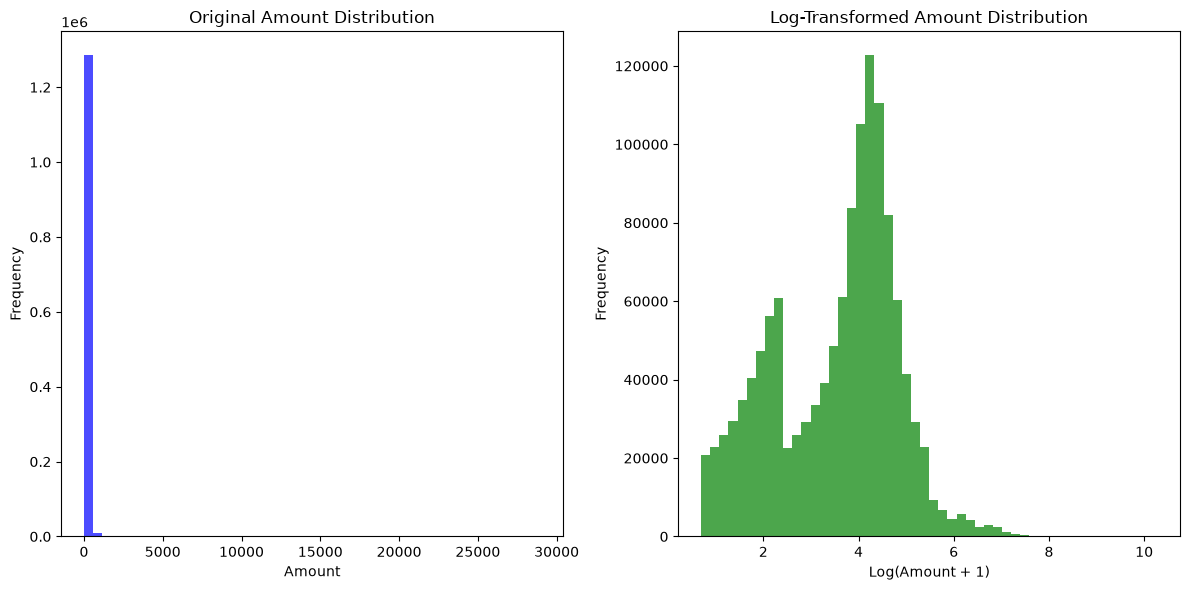

In [81]:
#Plotting a Histogram of the original and log-transformed 'amt' column to visualize the effect of the transformation.
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(df['amt'], bins=50, color='blue', alpha=0.7)
plt.title('Original Amount Distribution')
plt.xlabel('Amount')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(df['amt_log'], bins=50, color='green', alpha=0.7)
plt.title('Log-Transformed Amount Distribution')
plt.xlabel('Log(Amount + 1)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

 Does any amt equal 0?


In [83]:
zero_count = (df['amt'] == 0).sum()
print(f"Number of transactions with amount equal to zero: {zero_count}")

Number of transactions with amount equal to zero: 0


In [84]:
negative_count = (df['amt']<0).sum()
print(f"Number of transactions with amount less than zero: {negative_count}")

Number of transactions with amount less than zero: 0


In [85]:
#Smallest and largest transaction amounts
min_amt = df['amt'].min()
max_amt = df['amt'].max()
print(f"Smallest transaction amount: {min_amt}")
print(f"Largest transaction amount: {max_amt}")

Smallest transaction amount: 1.0
Largest transaction amount: 28948.9


Group by and compare fraud rate and count

In [87]:
category_stats  = df.groupby('category')['is_fraud'].agg(
    fraud_rate = 'mean',
    count = 'count'
)
print(category_stats)

                fraud_rate   count
category                          
entertainment     0.002478   94014
food_dining       0.001651   91461
gas_transport     0.004694  131659
grocery_net       0.002948   45452
grocery_pos       0.014098  123638
health_fitness    0.001549   85879
home              0.001608  123115
kids_pets         0.002114  113035
misc_net          0.014458   63287
misc_pos          0.003139   79655
personal_care     0.002424   90758
shopping_net      0.017561   97543
shopping_pos      0.007225  116672
travel            0.002864   40507


In [88]:
category_stats  = category_stats.sort_values(
    "fraud_rate",
    ascending=False
)
print(category_stats)

                fraud_rate   count
category                          
shopping_net      0.017561   97543
misc_net          0.014458   63287
grocery_pos       0.014098  123638
shopping_pos      0.007225  116672
gas_transport     0.004694  131659
misc_pos          0.003139   79655
grocery_net       0.002948   45452
travel            0.002864   40507
entertainment     0.002478   94014
personal_care     0.002424   90758
kids_pets         0.002114  113035
food_dining       0.001651   91461
home              0.001608  123115
health_fitness    0.001549   85879


In [90]:
top_3 = category_stats.head(3)
bottom_3 = category_stats.tail(3)

print("Top 3 categories with highest fraud rates:")
print(top_3)
print("\nBottom 3 categories with lowest fraud rates:")
print(bottom_3)


Top 3 categories with highest fraud rates:
              fraud_rate   count
category                        
shopping_net    0.017561   97543
misc_net        0.014458   63287
grocery_pos     0.014098  123638

Bottom 3 categories with lowest fraud rates:
                fraud_rate   count
category                          
food_dining       0.001651   91461
home              0.001608  123115
health_fitness    0.001549   85879


In [91]:
#Convert the rates to percentages
top_3['fraud_rate'] = top_3['fraud_rate'] * 100
bottom_3['fraud_rate'] = bottom_3['fraud_rate'] *100

print("Top 3 categories with highest fraud rates (in %):")
print(top_3)

print("\nBottom 3 categories with lowest fraud rates (in %):")
print(bottom_3)

Top 3 categories with highest fraud rates (in %):
              fraud_rate   count
category                        
shopping_net    1.756149   97543
misc_net        1.445795   63287
grocery_pos     1.409761  123638

Bottom 3 categories with lowest fraud rates (in %):
                fraud_rate   count
category                          
food_dining       0.165098   91461
home              0.160825  123115
health_fitness    0.154869   85879


In [ ]:
#Comparing the fraud rates of the top 3 and bottom 3 

risk_ratio = top_3['fraud_rate'].iloc[0] / bottom_3['fraud_rate'].iloc[0]
print(risk_ratio)

10.63702678112482


In [93]:
overall_rate = 0.0058

category_stats["relative_to_overall"] = (
    category_stats["fraud_rate"] / overall_rate
)

category_stats


,fraud_rate,count,relative_to_overall
category,,,
shopping_net,0.017561,97543,3.027842
misc_net,0.014458,63287,2.492749
grocery_pos,0.014098,123638,2.430622
shopping_pos,0.007225,116672,1.245756
gas_transport,0.004694,131659,0.809301
misc_pos,0.003139,79655,0.541127
grocery_net,0.002948,45452,0.508304
travel,0.002864,40507,0.493742
entertainment,0.002478,94014,0.427302


Fraud rate by hour of day

In [94]:
df['trans_date_trans_time']

0         2019-01-01 00:00:18
1         2019-01-01 00:00:44
2         2019-01-01 00:00:51
3         2019-01-01 00:01:16
4         2019-01-01 00:03:06
                  ...        
1296670   2020-06-21 12:12:08
1296671   2020-06-21 12:12:19
1296672   2020-06-21 12:12:32
1296673   2020-06-21 12:13:36
1296674   2020-06-21 12:13:37
Name: trans_date_trans_time, Length: 1296675, dtype: datetime64[us]

In [ ]:
df["hour"] = df["trans_date_trans_time"].dt.hour
#Extarcing the hour from the transaction timestamp

In [100]:
#Group by hour and calculate the fraud rate for each hour
hour_stat = df.groupby('hour')['is_fraud'].mean()

In [101]:
hour_stat

hour
0     0.014940
1     0.015349
2     0.014652
3     0.014239
4     0.001099
5     0.001423
6     0.000946
7     0.001327
8     0.001153
9     0.001114
10    0.000946
11    0.000998
12    0.001027
13    0.001225
14    0.001325
15    0.001208
16    0.001156
17    0.001192
18    0.001226
19    0.001236
20    0.000952
21    0.001129
22    0.028829
23    0.028374
Name: is_fraud, dtype: float64

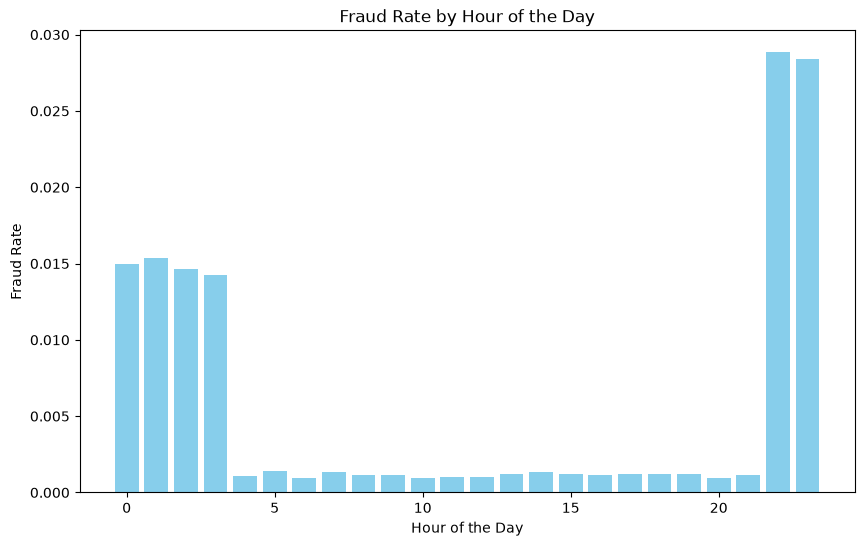

In [102]:
plt.figure(figsize=(10, 6))
plt.bar(hour_stat.index, hour_stat.values, color='skyblue')
plt.xlabel('Hour of the Day')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Hour of the Day')
plt.show()

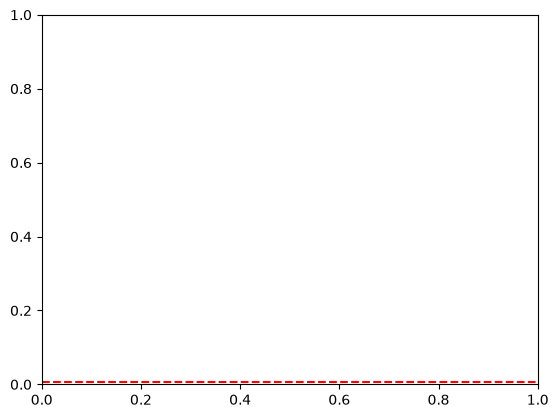

In [103]:
#Add overall fraud rate 

overall_fraud_rate = 0.0058

plt.axhline(
    overall_fraud_rate,
    color='red',
    linestyle='--',
    label=f'Overall Fraud Rate ({overall_fraud_rate*100:.2f}%)'
)

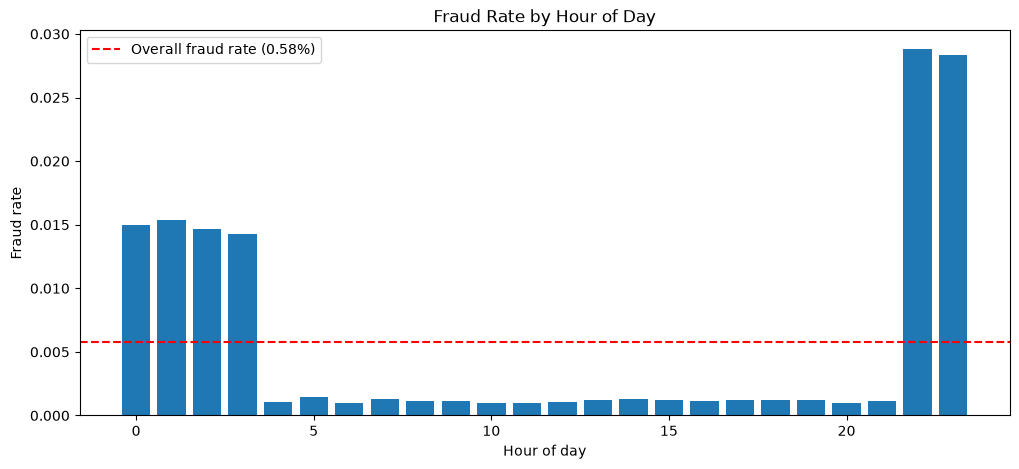

In [106]:

overall_rate = 0.0058

plt.figure(figsize=(12, 5))

plt.bar(hour_stat.index, hour_stat.values)

plt.axhline(
    overall_rate,
    color="red",
    linestyle="--",
    label="Overall fraud rate (0.58%)"
)

plt.xlabel("Hour of day")
plt.ylabel("Fraud rate")
plt.title("Fraud Rate by Hour of Day")
plt.legend()

plt.show()


In [107]:
#Above Average Fraud Rate Hours
above_avg = hour_stat[hour_stat > overall_rate]
print(above_avg)

hour
0     0.014940
1     0.015349
2     0.014652
3     0.014239
22    0.028829
23    0.028374
Name: is_fraud, dtype: float64


In [110]:
#Convert dob to datetime, like you did for the transaction time.

df['dob'] = pd.to_datetime(df['dob'], errors='coerce')


In [111]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

In [ ]:
#transaction date - birth date

age_days = (
    df["trans_date_trans_time"] - df["dob"]
).dt.days


In [115]:
#Convert days to years for better interpretability
age_years = age_days /365.25
df['age'] = np.floor(age_years).astype('int')

In [116]:
print("Min age",df['age'].min())
print("Max age",df['age'].max())

Min age 13
Max age 95


In [117]:
df[["dob", "trans_date_trans_time", "age"]].head(10)


,dob,trans_date_trans_time,age
0,1988-03-09,2019-01-01 00:00:18,30
1,1978-06-21,2019-01-01 00:00:44,40
2,1962-01-19,2019-01-01 00:00:51,56
3,1967-01-12,2019-01-01 00:01:16,51
4,1986-03-28,2019-01-01 00:03:06,32
5,1961-06-19,2019-01-01 00:04:08,57
6,1993-08-16,2019-01-01 00:04:42,25
7,1947-08-21,2019-01-01 00:05:08,71
8,1941-03-07,2019-01-01 00:05:18,77
9,1974-03-28,2019-01-01 00:06:01,44


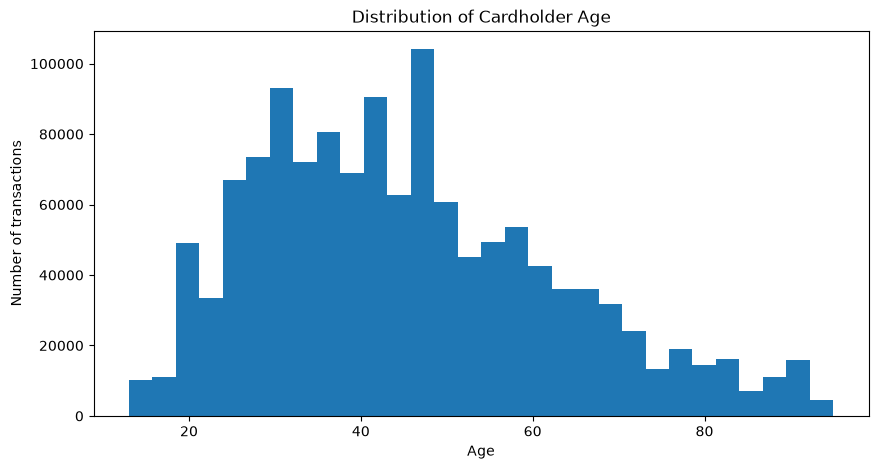

In [119]:
plt.figure(figsize=(10, 5))

plt.hist(df["age"], bins=30)

plt.xlabel("Age")
plt.ylabel("Number of transactions")
plt.title("Distribution of Cardholder Age")

plt.show()

In [120]:
#Age buckets
bins = [0, 25, 35, 45, 55, 65, 75, np.inf]
labels = [
    "Under 25",
    "25-35",
    "35-45",
    "45-55",
    "55-65",
    "65-75",
    "75+"
]

df["age_group"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels,
    right=False
)


In [122]:
df[['age','age_group']].head(10)

,age,age_group
0,30,25-35
1,40,35-45
2,56,55-65
3,51,45-55
4,32,25-35
5,57,55-65
6,25,25-35
7,71,65-75
8,77,75+
9,44,35-45


In [123]:
#Fraud rate by age group
age_stats = df.groupby(
    "age_group",
    observed=True

)['is_fraud'].agg(
    fraud_rate = 'mean',
    count = 'count'
)

In [124]:
age_stats["fraud_rate_percent"] = age_stats["fraud_rate"] * 100


In [125]:
age_stats.sort_values("fraud_rate", ascending=False)


,fraud_rate,count,fraud_rate_percent
age_group,,,
75+,0.009027,93274,0.902717
55-65,0.007673,164087,0.767276
Under 25,0.006278,121688,0.627835
65-75,0.005937,100384,0.593720
45-55,0.005812,256553,0.581166
25-35,0.004834,287749,0.483407
35-45,0.004261,272940,0.426101


In [128]:
#Task 7: Monthly fraud rate over the 18 train months

df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

In [130]:
#Extract year and month from the transaction timestamp
df['year'] = df['trans_date_trans_time'].dt.year
df['month'] = df['trans_date_trans_time'].dt.month

df['year_month'] = df['trans_date_trans_time'].dt.to_period('M')
monthly_stats = df.groupby("year_month")["is_fraud"].agg(
    fraud_rate="mean",
    count="count"
)


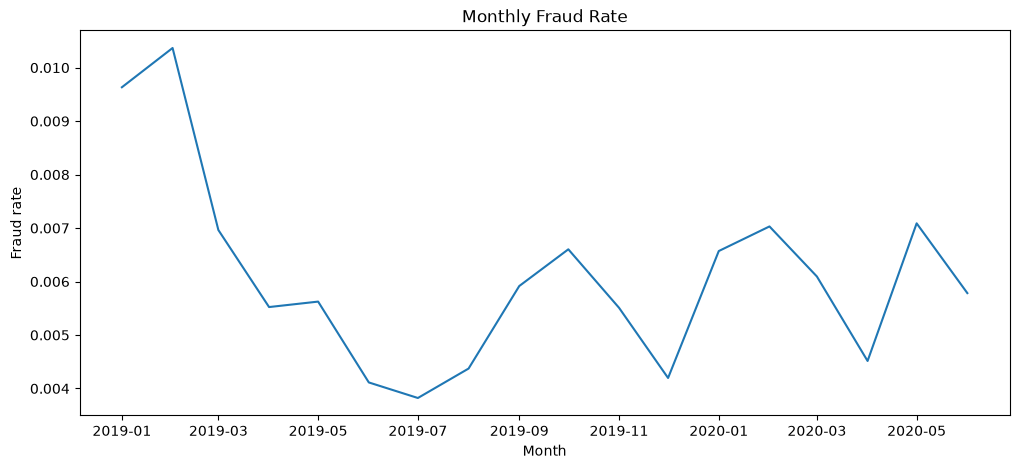

In [132]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_stats.index.to_timestamp(),
    monthly_stats["fraud_rate"]
)

plt.xlabel("Month")
plt.ylabel("Fraud rate")
plt.title("Monthly Fraud Rate")

plt.show()

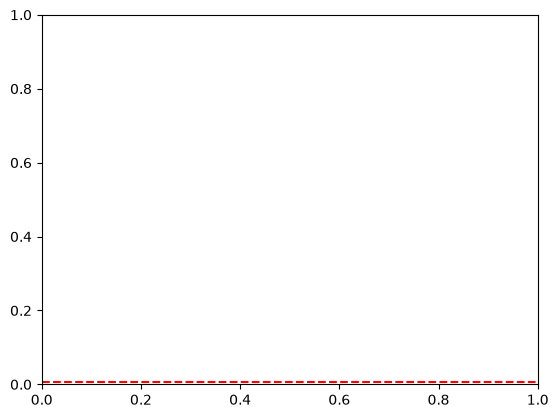

In [133]:
overall_rate = 0.0058

plt.axhline(
    overall_rate,
    color="red",
    linestyle="--",
    label="Overall fraud rate (0.58%)"
)


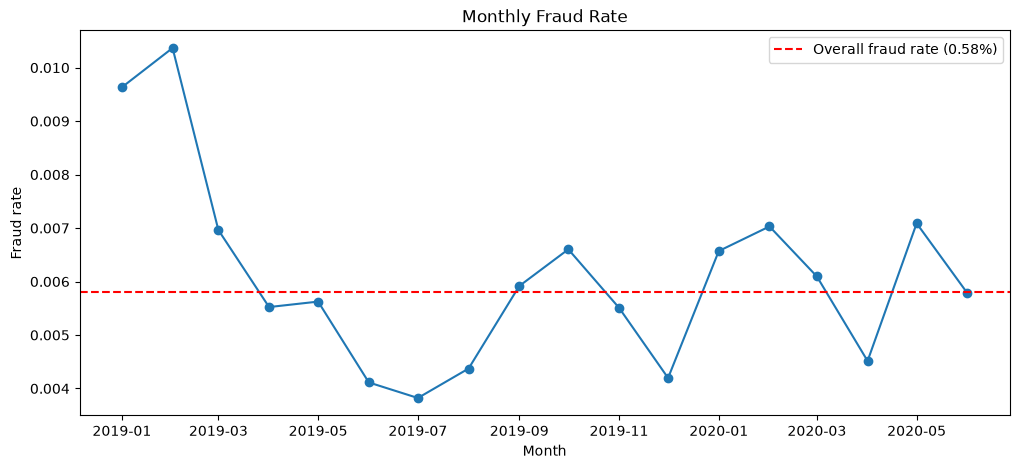

In [136]:
overall_rate = 0.0058

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_stats.index.to_timestamp(),
    monthly_stats["fraud_rate"],
    marker="o"
)

plt.axhline(
    overall_rate,
    color="red",
    linestyle="--",
    label="Overall fraud rate (0.58%)"
)

plt.xlabel("Month")
plt.ylabel("Fraud rate")
plt.title("Monthly Fraud Rate")
plt.legend()

plt.show()

In [137]:
test_rate = 0.0039

print("Lowest train month:", monthly_stats["fraud_rate"].min())
print("Highest train month:", monthly_stats["fraud_rate"].max())
print("Test rate:", test_rate)


Lowest train month: 0.0038223474525382233
Highest train month: 0.010367785665583764
Test rate: 0.0039
